# Multi-Agent Debate — Analysis & Plots

Reads CSVs produced by `analyze.py` and generates paper-ready figures.

**Usage:** Run `python analyze.py --all` first, then run this notebook.

DATA_SUBDIR='eval' — Found 8 experiments: ['baseline', 'bss', 'dss', 'accuracy_bss', 'binary_bss', 'random_binary', 'random_bss', 'warning_only']


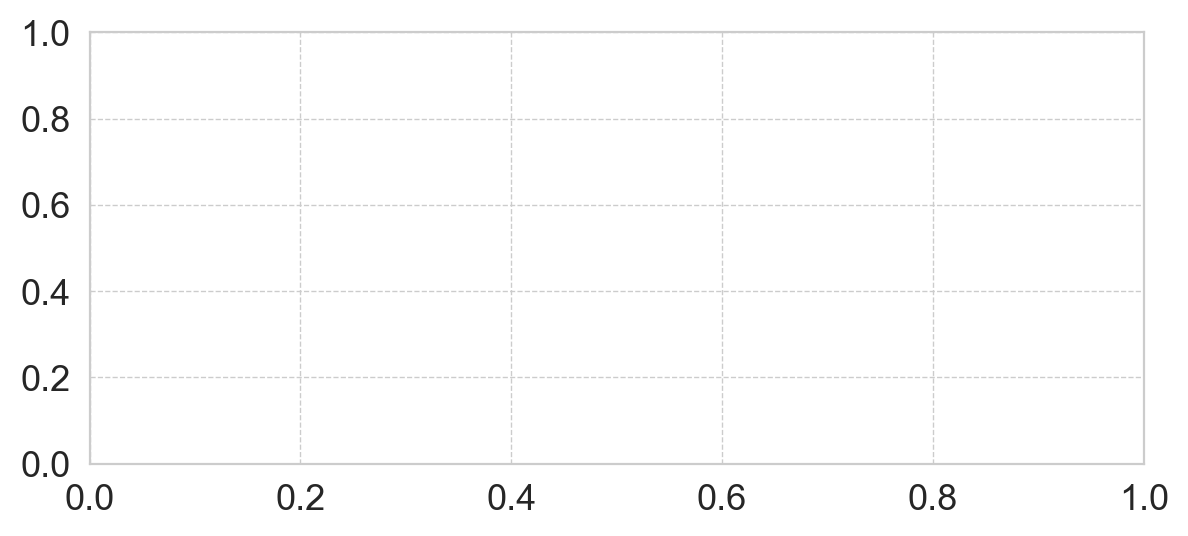

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import json, os
from pathlib import Path
from collections import OrderedDict

# ── Style (paper-ready) ───────────────────────────────────────────
plt.rcParams.update({
    # Font (LaTeX-like)
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    
    # Sizes tuned for 1-column figures
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,

    # Figure resolution
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Lines
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.5,
})

sns.set_style("whitegrid", {
    "grid.linestyle": "--",
    "grid.alpha": 0.3
})

PALETTE = OrderedDict([
    ("baseline",      "#4A90E2"),
    ("bss",           "#E24A4A"),
    ("dss",           "#50C878"),
    ("accuracy_bss",  "#9B59B6"),
    ("binary_bss",    "#F5A623"),
    ("random_binary", "#1B998B"),
    ("random_bss",    "#E377C2"),
    ("warning_only",  "#BCBD22"),
])
    
fig, ax = plt.subplots(figsize=(6.8, 2.8))  # wide + compact


# plt.rcParams.update({
#     "font.size": 14,
#     "axes.titlesize": 16,
#     "axes.labelsize": 16,
#     "xtick.labelsize": 13,
#     "ytick.labelsize": 13,
#     "legend.fontsize": 12,
#     "figure.dpi": 150,
#     "savefig.dpi": 300,
#     "savefig.bbox": "tight",
# })
# sns.set_style("whitegrid")

# PALETTE = OrderedDict([
#     ("baseline",     "#4A90E2"),
#     ("bss",          "#E24A4A"),
#     ("dss",          "#50C878"),
#     ("binary_bss",   "#F5A623"),
#     ("accuracy_bss", "#9B59B6"),
#     ("random_bss",   "#95A5A6"),
# ])

NICE_NAMES = {
    "baseline": "Baseline",
    "bss": "BSS",
    "dss": "DSS",
    "binary_bss": "Binary BSS",
    "accuracy_bss": "Accuracy BSS",
    "random_bss": "Random BSS",
    "random_binary": "Random Binary",
    "warning_only": "Warning Only",
}

MODEL_ORDER = ["llama3b", "llama8b", "qwen3b", "qwen7b", "qwen14b", "qwen32b", "majority"]

MODEL_PALETTE = OrderedDict([
    ("llama3b",  "#E24A4A"),
    ("llama8b",  "#F5A623"),
    ("qwen3b",   "#50C878"),
    ("qwen7b",   "#4A90E2"),
    ("qwen14b",  "#9B59B6"),
    ("qwen32b",  "#2C3E50"),
    ("majority", "#95A5A6"),
])

def exp_color(exp):
    return PALETTE.get(exp, "#333333")

def exp_colors(exps):
    return [exp_color(e) for e in exps]

def model_color(model):
    return MODEL_PALETTE.get(model, "#333333")

def model_colors(models):
    return [model_color(m) for m in models]

# ═══════════════════════════════════════════════════════════════════
# CONFIG — edit these paths to point at your data
# ═══════════════════════════════════════════════════════════════════
LOGS_DIR = Path("logs")           # root dir containing experiment folders
FIGS_DIR = Path("figures")        # where plots are saved

# Option 1: auto-discover all experiments that have analysis/ output
# EXPERIMENTS = None

# Option 2: list exactly the experiments you want, in the order you want
# EXPERIMENTS = ["baseline", "bss", "dss"]

# Option 3: point at arbitrary paths (keys become experiment names in plots)
# EXPERIMENT_PATHS = {
#     "baseline_v2": Path("/some/other/place/baseline/analysis"),
#     "bss_250":     Path("logs/bss_250/analysis"),
# }

EXPERIMENTS = None     # set to a list to override auto-discovery
EXPERIMENT_PATHS = {}  # set to a dict to use arbitrary paths
# Subfolder: "analysis" (analyze.py) or "eval" (evaluate.py). Or run the next notebook cell to switch.
DATA_SUBDIR = "eval"
# ═══════════════════════════════════════════════════════════════════

FIGS_DIR.mkdir(exist_ok=True)

# Legend placement: centered above the axes (heatmap cells keep defaults — no separate legend)
LEGEND_KW = dict(loc="upper center", bbox_to_anchor=(0.5, 1.14), framealpha=0.95)
LEGEND_FIG_KW = dict(loc="upper center", bbox_to_anchor=(0.5, 1.0), framealpha=0.95)

def _marker_csv():
    """Presence of this file under logs/<exp>/<DATA_SUBDIR>/ triggers auto-discovery."""
    return "final_accuracy.csv" if DATA_SUBDIR == "eval" else "accuracy.csv"


# Grouped-bar / legend order (left → right within each model)
EXPERIMENT_ORDER = [
    "baseline", "bss", "dss", "accuracy_bss", "binary_bss",
    "random_binary", "random_bss", "warning_only",
]


def _order_experiments(exps):
    """Sort experiment names to match EXPERIMENT_ORDER; unknown names last, then A–Z."""
    rank = {k: i for i, k in enumerate(EXPERIMENT_ORDER)}
    return sorted(exps, key=lambda e: (rank.get(e, 10_000), e))


if EXPERIMENT_PATHS:
    EXPERIMENTS = _order_experiments(list(EXPERIMENT_PATHS.keys()))
elif EXPERIMENTS is None:
    EXPERIMENTS = [d for d in sorted(os.listdir(LOGS_DIR))
                   if (LOGS_DIR / d / DATA_SUBDIR / _marker_csv()).exists()]
    EXPERIMENTS = _order_experiments(EXPERIMENTS)
else:
    EXPERIMENTS = _order_experiments(EXPERIMENTS)


def _data_dir(exp):
    """CSV directory: logs/<exp>/analysis/ or logs/<exp>/eval/."""
    if exp in EXPERIMENT_PATHS:
        return Path(EXPERIMENT_PATHS[exp])
    return LOGS_DIR / exp / DATA_SUBDIR


def _analysis_dir(exp):
    """Backward-compatible alias for _data_dir."""
    return _data_dir(exp)


print(f"DATA_SUBDIR={DATA_SUBDIR!r} — Found {len(EXPERIMENTS)} experiments: {EXPERIMENTS}")


In [ ]:
# ── Load CSVs into dicts (analyze.py `analysis/` or evaluate.py `eval/`) ──
accuracy = {}
flips = {}
flip_raw = {}
influence = {}
round_traj = {}
sycophancy = {}
subject_acc = {}
summaries = {}
knowledge_acc = {}
convergence = {}
bss_scores = {}
round1_final = {}
stability = {}


def _records_from_jsonl(path: Path) -> list:
    """Same records as analyze.load_log_from_path (no print). Used to build flip_raw when using eval/."""
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            for conv_id, record in obj.items():
                record["conversation_id"] = conv_id
                records.append(record)
    return records


def load_all_csvs():
    """Fill dicts from DATA_SUBDIR. Eval outputs are normalized to match analysis column names."""
    global accuracy, flips, flip_raw, influence, round_traj, sycophancy
    global subject_acc, summaries, knowledge_acc, convergence, bss_scores
    global round1_final, stability

    accuracy.clear()
    flips.clear()
    flip_raw.clear()
    influence.clear()
    round_traj.clear()
    sycophancy.clear()
    subject_acc.clear()
    summaries.clear()
    knowledge_acc.clear()
    convergence.clear()
    bss_scores.clear()
    round1_final.clear()
    stability.clear()

    for exp in EXPERIMENTS:
        d = _data_dir(exp)
        if DATA_SUBDIR == "eval":
            accuracy[exp] = pd.read_csv(d / "final_accuracy.csv").rename(
                columns={"final_accuracy": "accuracy"}
            )
            accuracy[exp]["null_rate"] = np.nan
            if "n_samples" in accuracy[exp].columns:
                accuracy[exp]["n_valid"] = accuracy[exp]["n_samples"]

            if (d / "flip_rates.csv").exists():
                flips[exp] = pd.read_csv(d / "flip_rates.csv")

            if (d / "influence.csv").exists():
                influence[exp] = pd.read_csv(d / "influence.csv")

            if (d / "round_accuracy.csv").exists():
                rt = pd.read_csv(d / "round_accuracy.csv")
                if "n_samples" in rt.columns:
                    rt = rt.rename(columns={"n_samples": "n"})
                rt = rt.copy()
                rt["round"] = rt["round"] + 1
                round_traj[exp] = rt

            if (d / "post_sycophancy.csv").exists():
                post = pd.read_csv(d / "post_sycophancy.csv")
                post = post.rename(columns={"post_syco": "syco_rate", "n_samples": "n"})
                sycophancy[exp] = post

            if (d / "per_subject_accuracy.csv").exists():
                subject_acc[exp] = pd.read_csv(d / "per_subject_accuracy.csv")

            if (d / "summary.json").exists():
                with open(d / "summary.json") as f:
                    summaries[exp] = json.load(f)
        else:
            accuracy[exp] = pd.read_csv(d / "accuracy.csv")
            if (d / "flip_summary.csv").exists():
                flips[exp] = pd.read_csv(d / "flip_summary.csv")
            if (d / "flips.csv").exists():
                flip_raw[exp] = pd.read_csv(d / "flips.csv")
            if (d / "influence.csv").exists():
                influence[exp] = pd.read_csv(d / "influence.csv")
            if (d / "round_trajectory.csv").exists():
                round_traj[exp] = pd.read_csv(d / "round_trajectory.csv")
            if (d / "sycophancy_summary.csv").exists():
                sycophancy[exp] = pd.read_csv(d / "sycophancy_summary.csv")
            if (d / "subject_accuracy.csv").exists():
                subject_acc[exp] = pd.read_csv(d / "subject_accuracy.csv")
            if (d / "summary.json").exists():
                with open(d / "summary.json") as f:
                    summaries[exp] = json.load(f)
            if (d / "knowledge_gated_accuracy.csv").exists():
                knowledge_acc[exp] = pd.read_csv(d / "knowledge_gated_accuracy.csv")
            if (d / "convergence.csv").exists():
                convergence[exp] = pd.read_csv(d / "convergence.csv")
            bss_path = d / "bss_scores.csv"
            if bss_path.exists():
                try:
                    bss_scores[exp] = pd.read_csv(bss_path)
                except pd.errors.EmptyDataError:
                    pass
            if (d / "round1_vs_final.csv").exists():
                round1_final[exp] = pd.read_csv(d / "round1_vs_final.csv")
            if (d / "stability.csv").exists():
                stability[exp] = pd.read_csv(d / "stability.csv")

    print(f"Loaded ({DATA_SUBDIR!r}).")


load_all_csvs()

Loaded ('eval').


In [8]:
for exp in EXPERIMENTS:
    print(exp, sorted(accuracy[exp]["model"].tolist()))

accuracy_bss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
baseline ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
binary_bss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
bss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
dss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
random_binary ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
random_bss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
warning_only ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']


## 1. Cross-Experiment Accuracy Comparison

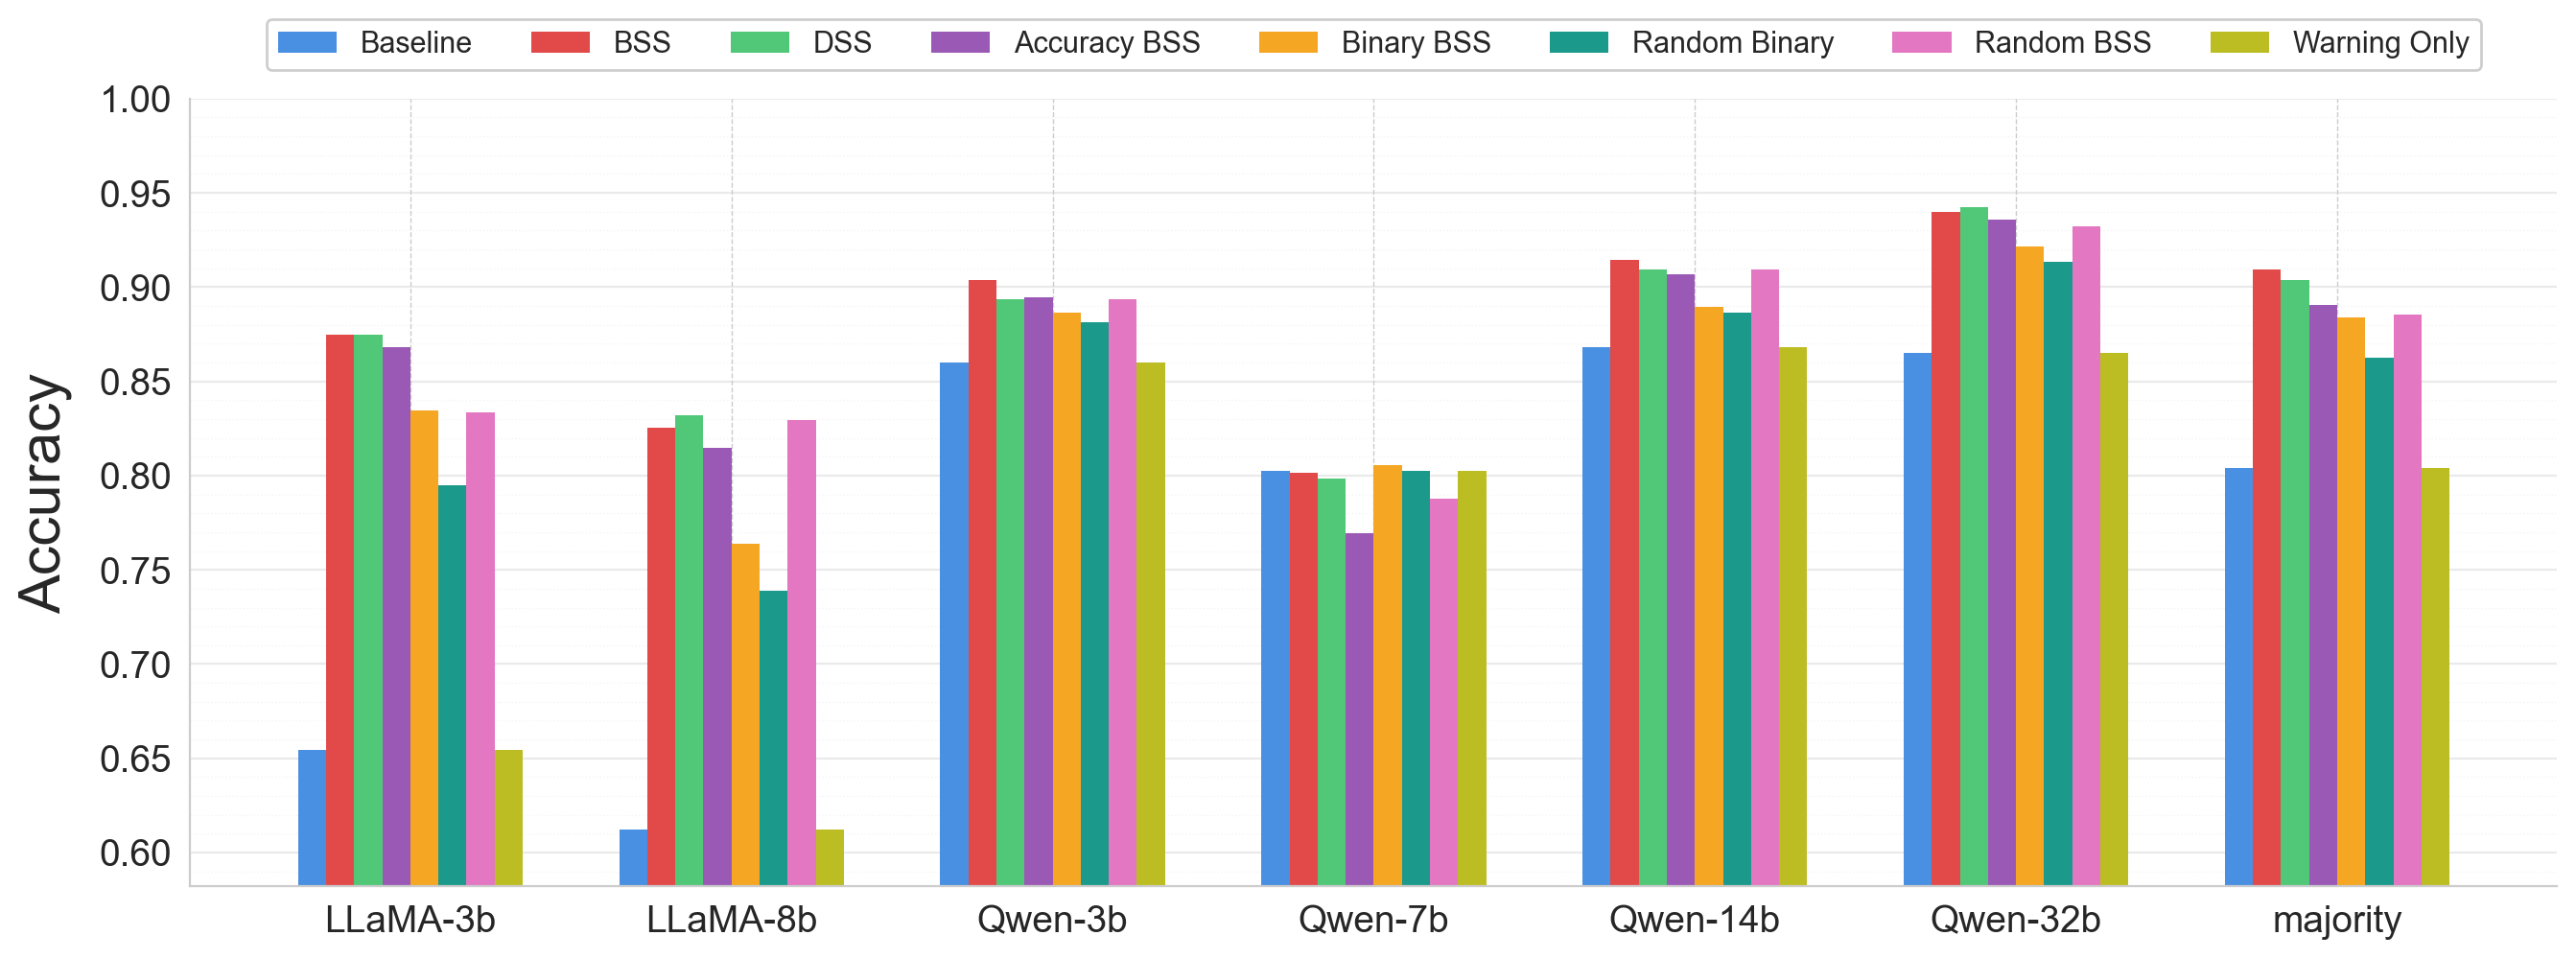

In [27]:
rows = []
for exp in EXPERIMENTS:
    for _, r in accuracy[exp].iterrows():
        rows.append({"experiment": exp, "model": r["model"],
                     "accuracy": r["accuracy"], "null_rate": r["null_rate"]})

comp_df = pd.DataFrame(rows)
comp_df["model"] = pd.Categorical(comp_df["model"], categories=MODEL_ORDER, ordered=True)
comp_df = comp_df.sort_values(["model", "experiment"])

fig, ax = plt.subplots(figsize=(14, 6.5))
models_in_data = [m for m in MODEL_ORDER if m in comp_df["model"].unique()]
x = np.arange(len(models_in_data))
n_exp = len(EXPERIMENTS)
width = 0.7 / n_exp   # slightly tighter

for i, exp in enumerate(EXPERIMENTS):
    exp_data = comp_df[comp_df["experiment"] == exp].set_index("model")
    vals = [exp_data.loc[m, "accuracy"] if m in exp_data.index else np.nan for m in models_in_data]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=NICE_NAMES.get(exp, exp),
        color=exp_color(exp),
        edgecolor="none"
    )

ax.set_ylabel("Accuracy", fontsize=22, labelpad=10)
ax.set_xticks(x + width * (n_exp - 1) / 2)
ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_in_data], fontsize=14)

# Include low scores: fixed 0.85–1.0 hid bars when accuracy < 0.85 (LLaMA-8b, baselines, Qwen-7b).
_ymin = max(0.0, float(np.nanmin(comp_df["accuracy"].to_numpy())) - 0.03)
ax.set_ylim(_ymin, 1.0)
ax.tick_params(labelsize=14)

# Fine-grained y-axis ticks for better granularity
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))

# Enhanced gridlines (major and minor)
ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

sns.despine(left=False, bottom=False)

ax.legend(ncol=len(EXPERIMENTS), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)

fig.tight_layout(rect=[0, 0, 1, 0.82])
fig.savefig(FIGS_DIR / "accuracy_comparison.pdf")


# for i, exp in enumerate(EXPERIMENTS):
#     exp_data = comp_df[comp_df["experiment"] == exp].set_index("model")
#     vals = [exp_data.loc[m, "accuracy"] if m in exp_data.index else 0 for m in models_in_data]
#     ax.bar(x + i * width, vals, width, label=NICE_NAMES.get(exp, exp),
#            color=exp_color(exp), edgecolor="white", linewidth=0.5)

# ax.set_xticks(x + width * (n_exp - 1) / 2)
# ax.set_xticklabels(models_in_data)
# ax.set_ylabel("Final Accuracy")
# ax.legend(ncol=len(EXPERIMENTS), **LEGEND_KW)
# ax.set_ylim(0.5, 1.0)
# ax.axhline(0.5, color="grey", ls="--", lw=0.5)
# sns.despine()
# fig.tight_layout(rect=[0, 0, 1, 0.88])
# fig.savefig(FIGS_DIR / "accuracy_comparison.pdf")
# fig.savefig(FIGS_DIR / "accuracy_comparison.png")
# plt.show()


In [28]:
# Print the numbers as a clean table
pivot = comp_df.pivot_table(index="experiment", columns="model", values="accuracy")
_prow = [e for e in EXPERIMENT_ORDER if e in pivot.index]
_extra = [e for e in pivot.index if e not in EXPERIMENT_ORDER]
pivot = pivot.reindex(_prow + sorted(_extra))
pivot = pivot[[m for m in MODEL_ORDER if m in pivot.columns]]
# Rename columns to match chart labels
pivot.columns = [c.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for c in pivot.columns]
pivot.index.name = None  # Remove the "experiment" label from the index
display(pivot.round(4).style.background_gradient(cmap="RdYlGn", axis=None, vmin=0.6, vmax=1.0))

/var/folders/h3/d4qhj3nn6j505hsm3ks5sr540000gn/T/ipykernel_6669/4237203391.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = comp_df.pivot_table(index="experiment", columns="model", values="accuracy")


,LLaMA-3b,LLaMA-8b,Qwen-3b,Qwen-7b,Qwen-14b,Qwen-32b,majority
baseline,0.654700,0.612000,0.860000,0.802700,0.868000,0.865300,0.804000
bss,0.874700,0.825300,0.904000,0.801300,0.914700,0.940000,0.909300
dss,0.874700,0.832000,0.893300,0.798700,0.909300,0.942700,0.904000
accuracy_bss,0.868000,0.814700,0.894700,0.769300,0.906700,0.936000,0.890700
binary_bss,0.834700,0.764000,0.886700,0.805300,0.889300,0.921300,0.884000
random_binary,0.794700,0.738700,0.881300,0.802700,0.886700,0.913300,0.862700
random_bss,0.833300,0.829300,0.893300,0.788000,0.909300,0.932000,0.885300
warning_only,0.654700,0.612000,0.860000,0.802700,0.868000,0.865300,0.804000


## 4. Influence Heatmaps

/var/folders/h3/d4qhj3nn6j505hsm3ks5sr540000gn/T/ipykernel_6669/2420144422.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.04, 0.06, 0.98, 0.94])


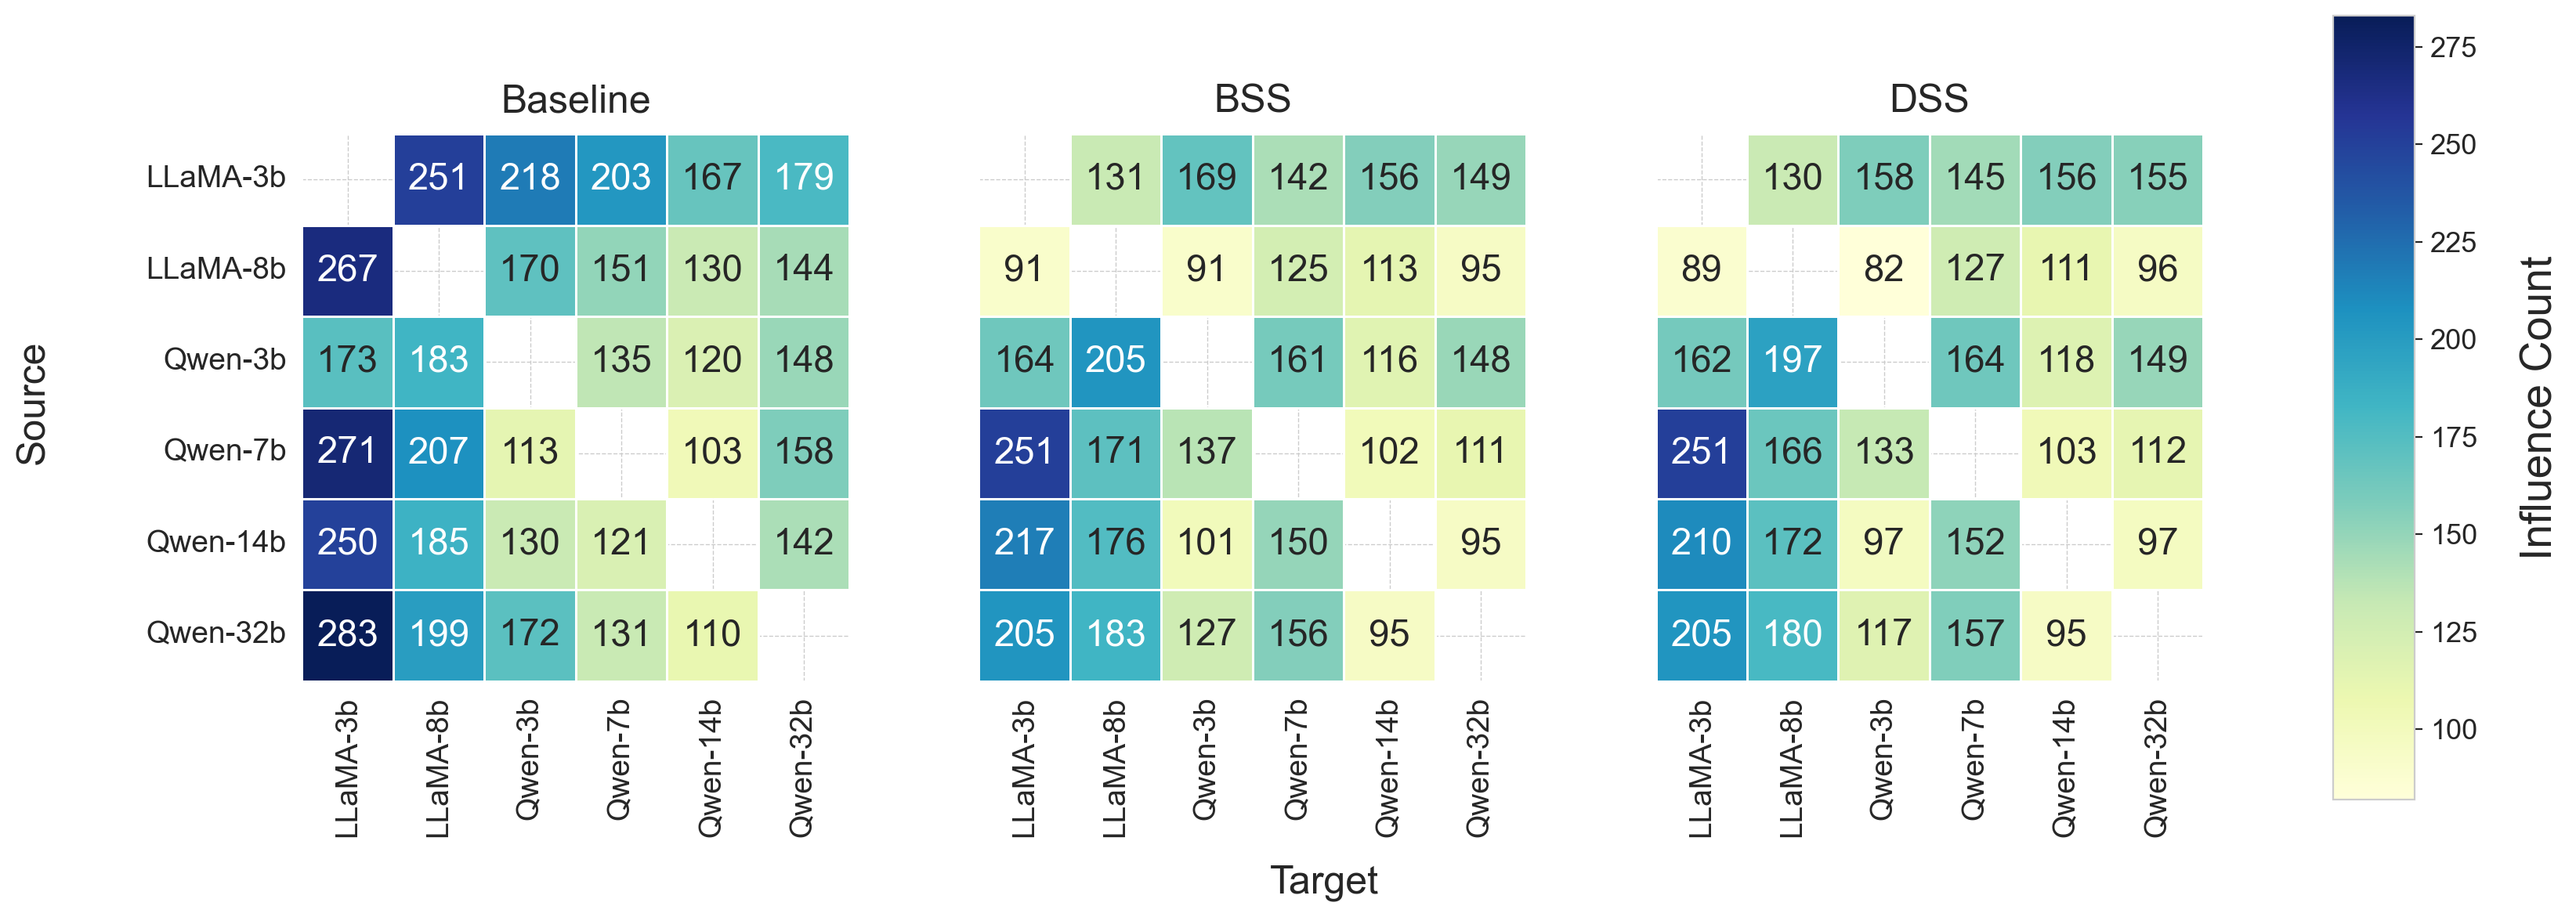

In [29]:
preferred = ["baseline", "bss", "dss"]
exps_to_show = [e for e in preferred if e in influence]
if not exps_to_show:
    exps_to_show = [e for e in EXPERIMENTS if e in influence][:3]

from matplotlib.gridspec import GridSpec

if exps_to_show:
    # Build matrices and a common model order + color scale
    matrices = []
    models_union = []
    for exp in exps_to_show:
        idf = influence[exp]
        if idf.empty:
            matrices.append(None)
            continue
        ml = sorted(set(idf["source"]) | set(idf["target"]))
        ml = [m for m in MODEL_ORDER if m in ml and m != "majority"]
        models_union.extend(ml)
        mat = pd.DataFrame(np.nan, index=ml, columns=ml)
        for _, r in idf.iterrows():
            if r["source"] in ml and r["target"] in ml:
                mat.loc[r["source"], r["target"]] = r["count"]
        for i, m in enumerate(ml):
            mat.iloc[i, i] = np.nan  # no self-influence on diagonal
        matrices.append(mat)

    models_list = [m for m in MODEL_ORDER if m in set(models_union) and m != "majority"]
    for j in range(len(matrices)):
        if matrices[j] is None:
            continue
        matrices[j] = matrices[j].reindex(index=models_list, columns=models_list)

    vals = np.concatenate([m.values.ravel() for m in matrices if m is not None])
    vals = vals[~np.isnan(vals)]
    vmin, vmax = (float(vals.min()), float(vals.max())) if len(vals) else (0.0, 1.0)

    n = len(exps_to_show)
    # Three equal-width heatmap panels + separate colorbar column (same size for all heatmaps)
    fig = plt.figure(figsize=(5.4 * n + 1.2, 6.5))
    gs = GridSpec(1, n + 1, figure=fig, width_ratios=[1] * n + [0.15], wspace=0.30)
    axes = [fig.add_subplot(gs[0, j]) for j in range(n)]
    cax = fig.add_subplot(gs[0, n])
    cbar_mappable = None

    for idx, exp in enumerate(exps_to_show):
        ax = axes[idx]
        mat = matrices[idx]
        if mat is None:
            ax.set_axis_off()
            continue
        mask = np.isnan(mat.values.astype(float))
        hm = sns.heatmap(
            mat.astype(float), ax=ax, annot=True, fmt=".0f",
            cmap="YlGnBu", mask=mask, linewidths=1, linecolor="white",
            square=True, annot_kws={"size": 17},
            vmin=vmin, vmax=vmax,
            cbar=False,
        )
        cbar_mappable = hm.collections[0]
        ax.set_title(NICE_NAMES.get(exp, exp), fontsize=18, pad=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        # Format model names to match chart labels (llama3b → LLaMA-3b, qwen3b → Qwen-3b)
        x_labels = [label.get_text().replace("llama", "LLaMA-").replace("qwen", "Qwen-") 
                    for label in ax.get_xticklabels()]
        y_labels = [label.get_text().replace("llama", "LLaMA-").replace("qwen", "Qwen-") 
                    for label in ax.get_yticklabels()]
        ax.set_xticklabels(x_labels, fontsize=14, rotation=90, ha="center")
        
        if idx == 0:
            ax.set_yticklabels(y_labels, fontsize=14)
        else:
            ax.set_yticklabels([])

    fig.supylabel("Source", fontsize=18, x=0.02)
    fig.supxlabel("Target", fontsize=18, y=0.01)

    if cbar_mappable is not None:
        cbar = fig.colorbar(cbar_mappable, cax=cax)
        cbar.set_label("Influence Count", fontsize=20, labelpad=20)
        cbar.ax.tick_params(labelsize=13)

    fig.tight_layout(rect=[0.04, 0.06, 0.98, 0.94])
    fig.savefig(FIGS_DIR / "influence_heatmaps.pdf")
    fig.savefig(FIGS_DIR / "influence_heatmaps.png")
    plt.show()


## 5. Round-by-Round Accuracy Trajectory

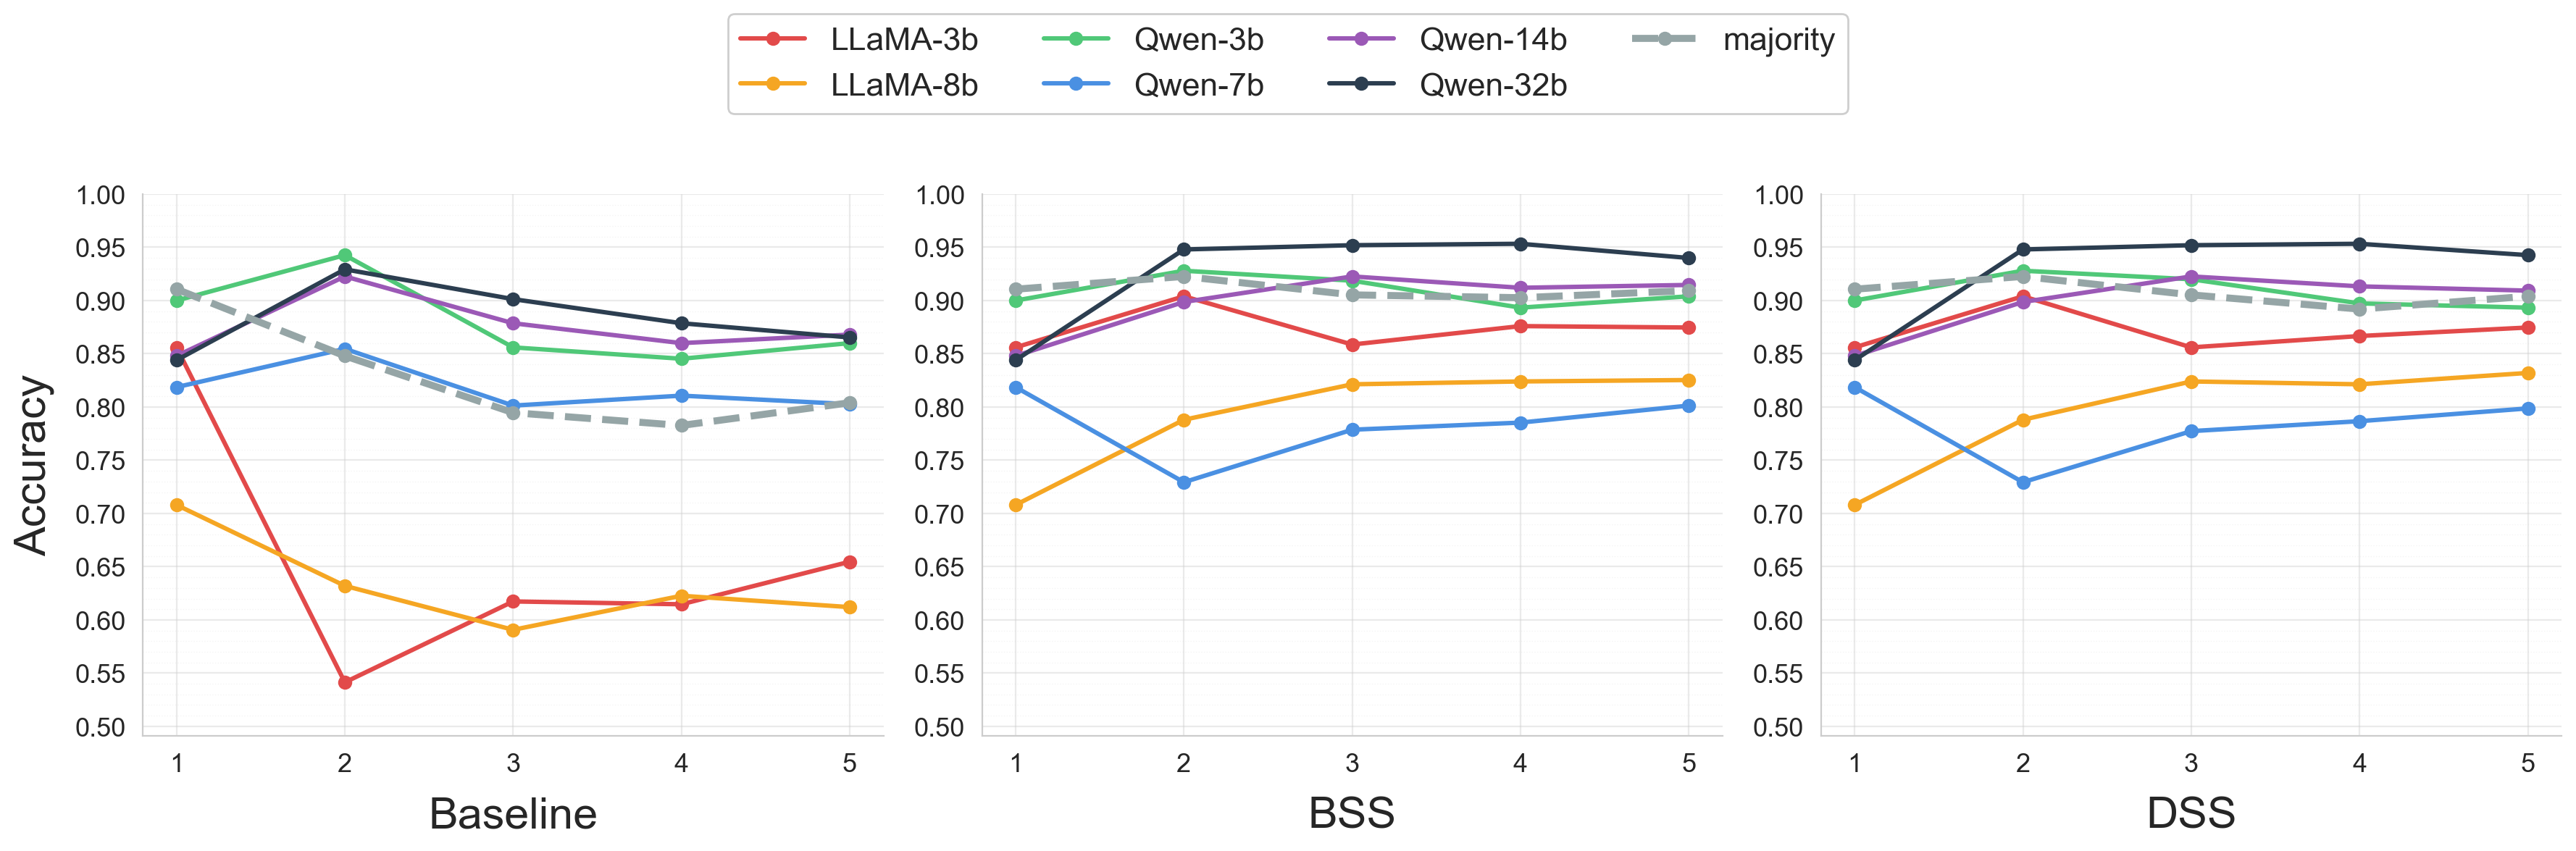

In [31]:
exps_traj = [e for e in ["baseline", "bss", "dss"] if e in round_traj]
if not exps_traj:
    exps_traj = list(round_traj.keys())[:3]

if exps_traj:
    fig, axes = plt.subplots(1, len(exps_traj), figsize=(6 * len(exps_traj), 6), squeeze=False)
    axes = axes[0]
    _acc_parts = [
        pd.to_numeric(round_traj[e]["accuracy"], errors="coerce").to_numpy()
        for e in exps_traj if e in round_traj and not round_traj[e].empty
    ]
    _all_acc = np.concatenate(_acc_parts) if _acc_parts else np.array([])
    if _all_acc.size:
        _mn = np.nanmin(_all_acc)
        _traj_ymin = max(0.0, float(_mn) - 0.05) if np.isfinite(_mn) else 0.5
    else:
        _traj_ymin = 0.5

    for idx, exp in enumerate(exps_traj):
        ax = axes[idx]
        df = round_traj[exp]
        for model in MODEL_ORDER:
            mdf = df[df["model"] == model]
            if mdf.empty:
                continue
            ls = "--" if model == "majority" else "-"
            lw = 3.5 if model == "majority" else 2.2  # Sharper, thicker lines
            model_display = model.replace("llama", "LLaMA-").replace("qwen", "Qwen-")
            ax.plot(mdf["round"], mdf["accuracy"], ls, lw=lw, label=model_display,
                    marker="o", ms=6, color=model_color(model), antialiased=True)
        
        ax.set_xlabel(NICE_NAMES.get(exp, exp), fontsize=22, labelpad=10)
        ax.set_ylabel("Accuracy" if idx == 0 else "", fontsize=22, labelpad=10)
        ax.set_ylim(_traj_ymin, 1.0)
        
        # Fine-grained y-axis ticks (0.05 intervals for better granularity)
        ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
        ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
        
        # Add minor gridlines for better readability
        ax.grid(True, which="major", alpha=0.4, linestyle="-", linewidth=0.8, zorder=0)
        ax.grid(True, which="minor", alpha=0.2, linestyle=":", linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)
        
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.tick_params(labelsize=13, length=5, width=1.2)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=4, fontsize=16, **LEGEND_FIG_KW)

    sns.despine()
    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "round_trajectory.pdf")
    fig.savefig(FIGS_DIR / "round_trajectory.png")
    plt.show()


## 6. Post-Discussion Sycophancy

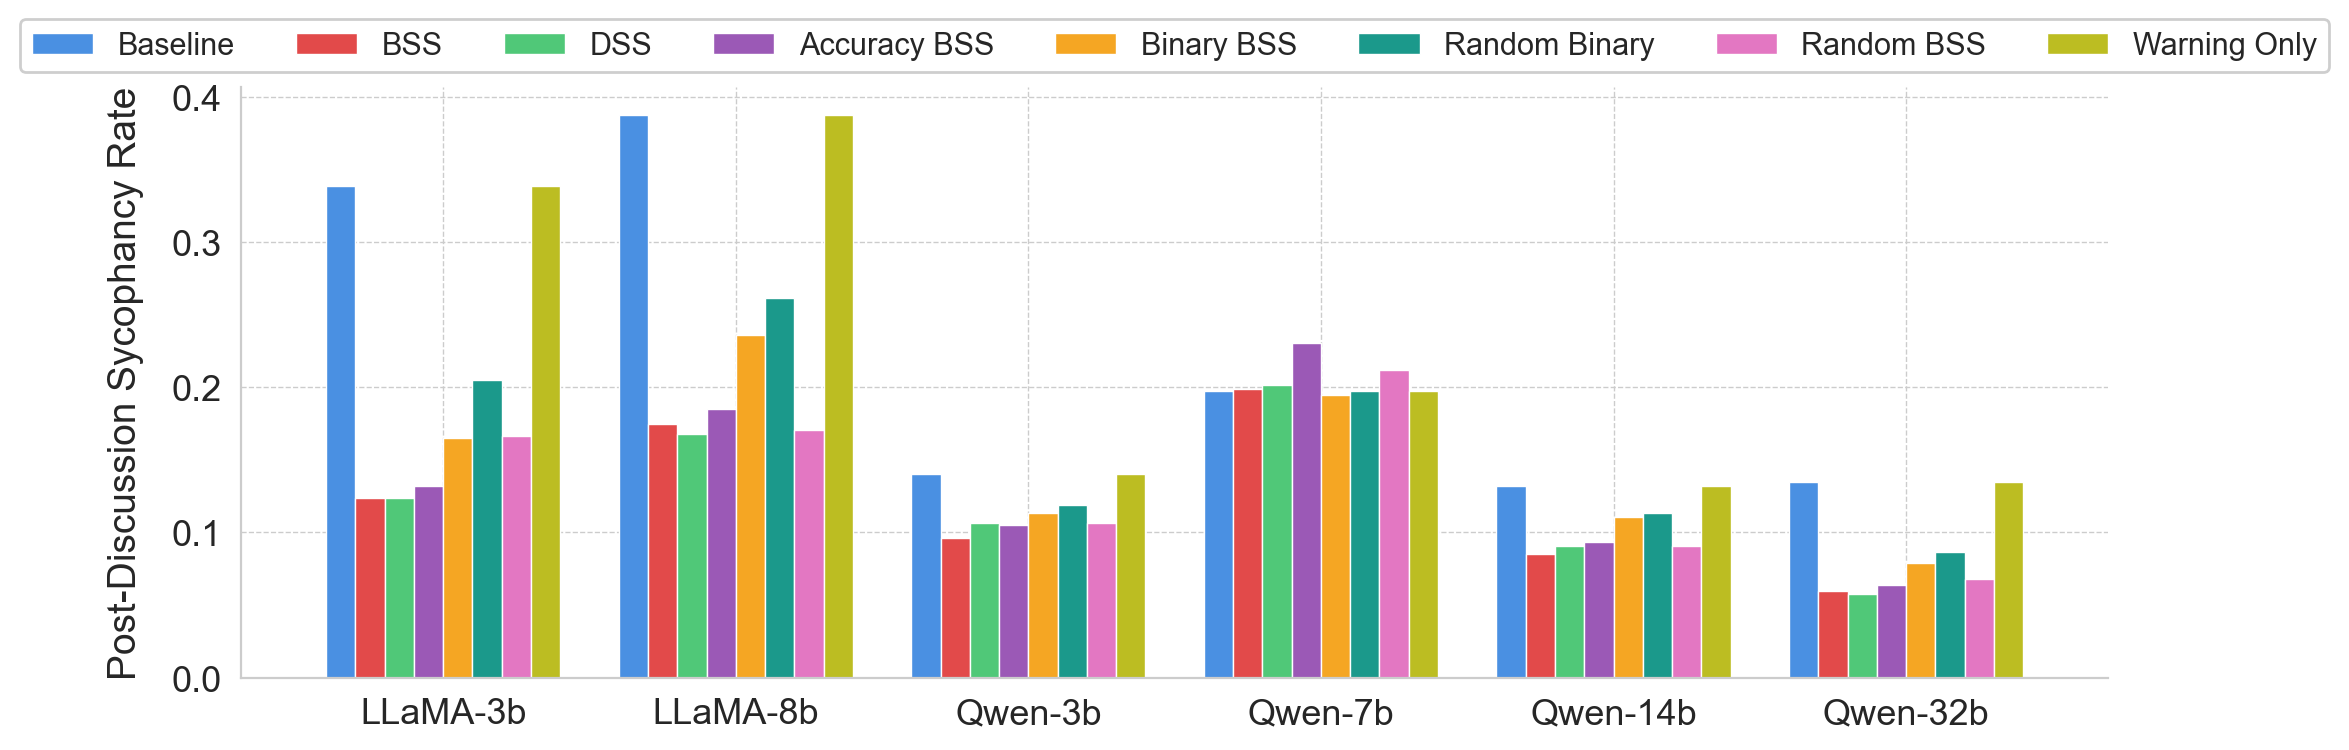

In [32]:
syco_rows = []
for exp in EXPERIMENTS:
    if exp in sycophancy:
        df = sycophancy[exp].copy()
        df["experiment"] = exp
        syco_rows.append(df)

if syco_rows:
    all_syco = pd.concat(syco_rows, ignore_index=True)
    avg_syco = all_syco.groupby(["experiment", "model"])["syco_rate"].mean().reset_index()
    avg_syco["model"] = pd.Categorical(avg_syco["model"],
                                        categories=[m for m in MODEL_ORDER if m != "majority"],
                                        ordered=True)

    fig, ax = plt.subplots(figsize=(12, 5))
    models_list = [m for m in MODEL_ORDER if m != "majority" and m in avg_syco["model"].unique()]
    x = np.arange(len(models_list))
    n_exp = len(EXPERIMENTS)
    width = 0.8 / n_exp

    for i, exp in enumerate(EXPERIMENTS):
        edf = avg_syco[avg_syco["experiment"] == exp].set_index("model")
        vals = [edf.loc[m, "syco_rate"] if m in edf.index else 0 for m in models_list]
        ax.bar(x + i * width, vals, width, label=NICE_NAMES.get(exp, exp),
               color=exp_color(exp), edgecolor="white", linewidth=0.5)

    ax.set_xticks(x + width * (n_exp - 1) / 2)
    ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_list], fontsize=13)
    ax.set_ylabel("Post-Discussion Sycophancy Rate", fontsize=14, labelpad=10)
    ax.tick_params(labelsize=13)
    ax.legend(ncol=len(EXPERIMENTS), **LEGEND_KW)
    sns.despine()
    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "sycophancy_comparison.pdf")
    fig.savefig(FIGS_DIR / "sycophancy_comparison.png")
    plt.show()


## 10. BSS Score vs Accuracy Delta (Core Hypothesis Test)

Does injecting sycophancy scores help more for models that *are* more sycophantic? This is the central claim of the paper.

In [33]:
if "baseline" in accuracy and "bss" in accuracy and "bss" in bss_scores:
    base_acc = accuracy["baseline"].set_index("model")["accuracy"]
    bss_acc = accuracy["bss"].set_index("model")["accuracy"]
    scores_df = bss_scores["bss"]

    avg_bss = scores_df.groupby("model")["bss_score"].mean()

    models_both = [m for m in avg_bss.index if m in base_acc.index and m in bss_acc.index and m != "majority"]
    scatter_data = pd.DataFrame({
        "model": models_both,
        "bss_score": [avg_bss[m] for m in models_both],
        "delta": [(bss_acc[m] - base_acc[m]) for m in models_both],
    })

    fig, ax = plt.subplots(figsize=(10, 7))
    for _, row in scatter_data.iterrows():
        ax.scatter(row["bss_score"], row["delta"],
                   s=200, c=model_color(row["model"]), edgecolors="white", linewidth=2, zorder=5)
        model_display = row["model"].replace("llama", "LLaMA-").replace("qwen", "Qwen-")
        ax.annotate(model_display, (row["bss_score"], row["delta"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=16, fontweight="bold")

    ax.axhline(0, color="grey", ls="--", lw=1.2, alpha=0.7)
    
    ax.set_xlabel("BSS Score (avg across metrics)", fontsize=22, labelpad=10)
    ax.set_ylabel("Accuracy Δ (BSS − Baseline)", fontsize=22, labelpad=10)
    
    # Fine-grained grid
    ax.grid(True, which="major", alpha=0.3, linestyle="-", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    
    # Enhanced tick styling
    ax.tick_params(labelsize=14, length=5, width=1.2)
    
    sns.despine()
    fig.tight_layout()
    fig.savefig(FIGS_DIR / "bss_score_vs_delta.pdf")
    fig.savefig(FIGS_DIR / "bss_score_vs_delta.png")
    plt.show()
else:
    print("Need both baseline and bss experiments with bss_scores.csv to plot this.")


Need both baseline and bss experiments with bss_scores.csv to plot this.


## 11. Per-Subject Accuracy Delta (BSS − Baseline)

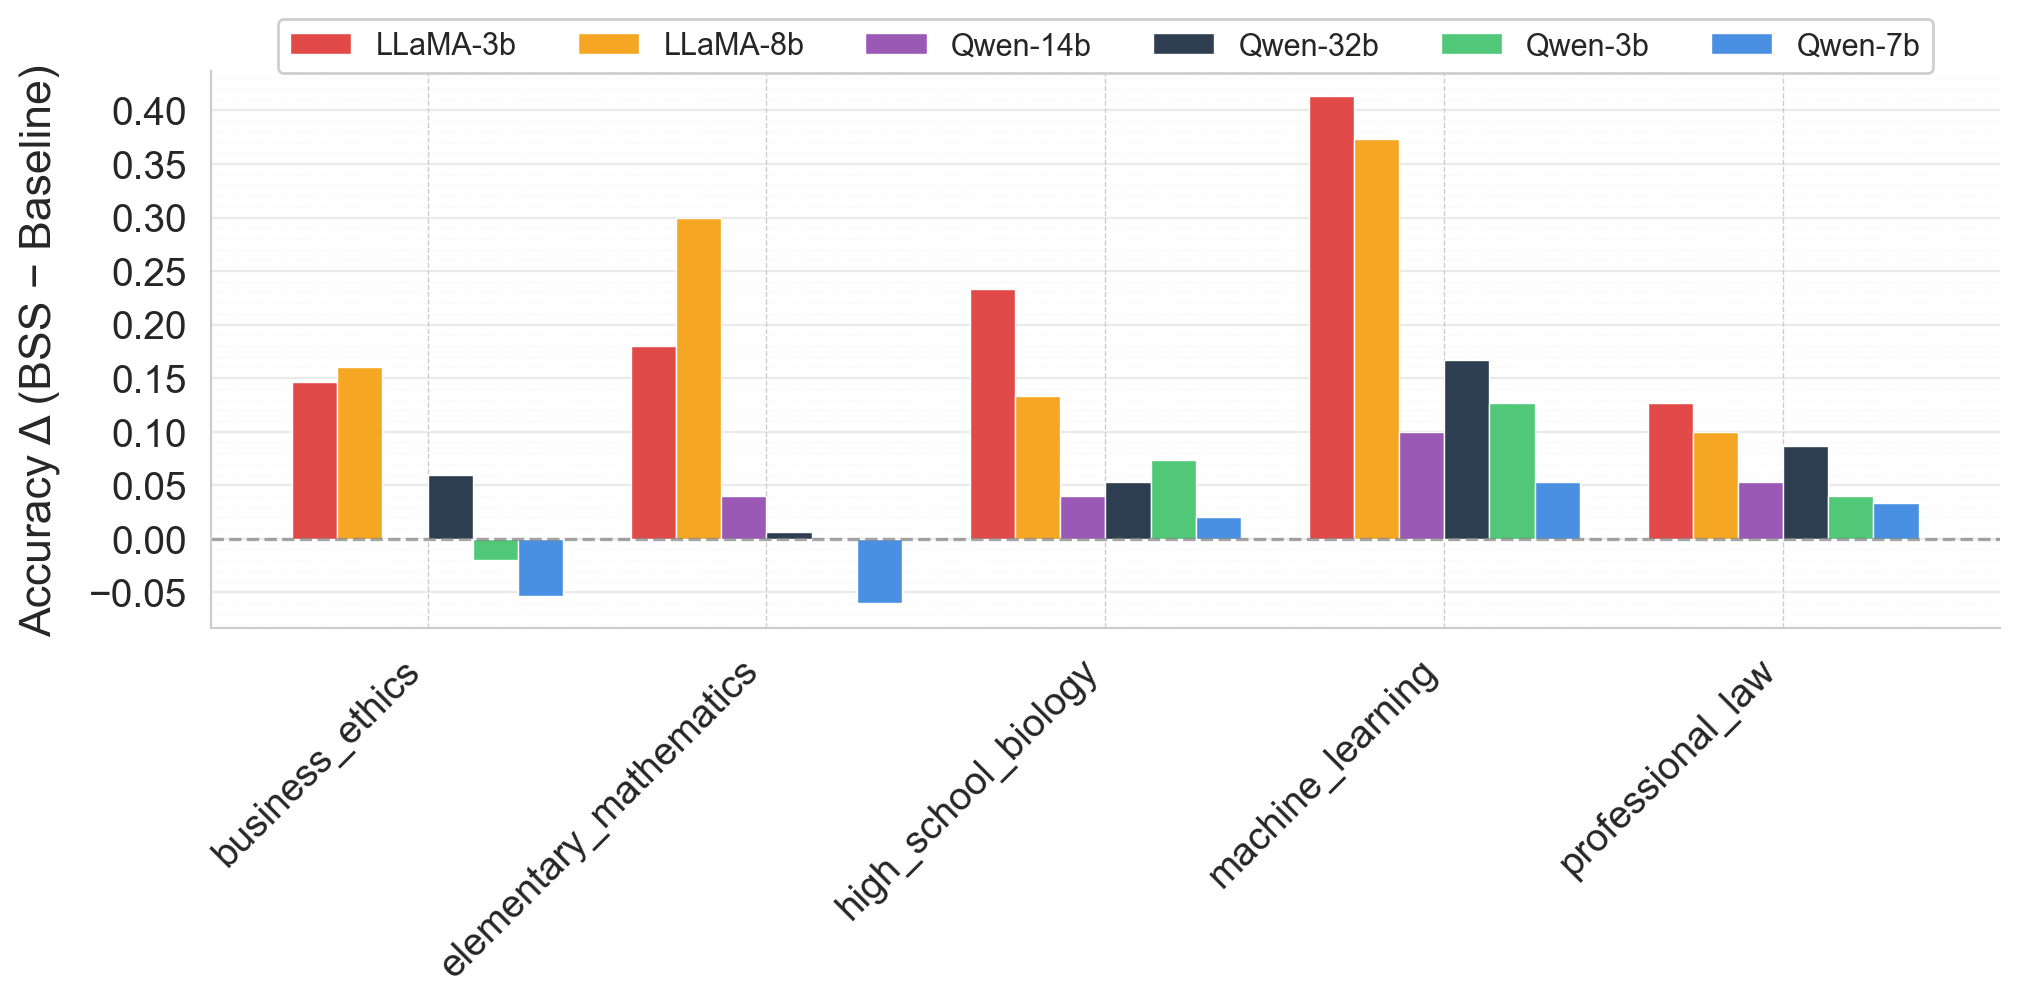

In [42]:
if "baseline" in subject_acc and "bss" in subject_acc:
    sa_base = subject_acc["baseline"]
    sa_bss = subject_acc["bss"]

    merged = sa_base.merge(sa_bss, on=["subject", "model"],
                           suffixes=("_base", "_bss"), how="inner")
    merged["delta"] = merged["accuracy_bss"] - merged["accuracy_base"]

    subjects = sorted(merged["subject"].unique())
    models = sorted(merged["model"].unique())

    fig, ax = plt.subplots(figsize=(max(12, len(subjects) * 0.9), 8.5))
    x = np.arange(len(subjects))
    width = 0.8 / max(len(models), 1)

    for i, model in enumerate(models):
        mdata = merged[merged["model"] == model].set_index("subject")
        deltas = [mdata.loc[s, "delta"] if s in mdata.index else 0 for s in subjects]
        model_display = model.replace("llama", "LLaMA-").replace("qwen", "Qwen-")
        ax.bar(x + i * width - 0.4 + width / 2, deltas, width,
               label=model_display, color=model_color(model), edgecolor="white", lw=0.5)

    ax.axhline(0, color="grey", ls="--", lw=1.2, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(subjects, rotation=45, ha="right", fontsize=11)
    ax.set_ylabel("Accuracy Δ (BSS − Baseline)", fontsize=16, labelpad=10)
    
    # Fine-grained y-axis ticks
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
    
    # Enhanced gridlines (major and minor)
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(ncol=len(models), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)
    sns.despine()
    fig.tight_layout(rect=[0.14, 0.15, 1, 0.82])
    fig.savefig(FIGS_DIR / "subject_accuracy_delta.pdf")
    fig.savefig(FIGS_DIR / "subject_accuracy_delta.png")
    plt.show()
else:
    print("Need baseline and bss subject_accuracy.csv to plot this.")

## 12. Knowledge-Gated Accuracy

Accuracy restricted to samples where `knowledge_flags[model] == True` — i.e., the model "knew" the answer before debate.
Shows whether scores help models *hold onto* correct answers rather than being swayed.

In [35]:
exps_kg = [e for e in EXPERIMENTS if e in knowledge_acc and not knowledge_acc[e].empty]
if exps_kg:
    kg_rows = []
    for exp in exps_kg:
        df = knowledge_acc[exp]
        for model, grp in df.groupby("model"):
            kg_rows.append({"experiment": exp, "model": model,
                            "accuracy": grp["is_correct"].mean(),
                            "n": len(grp)})
    kg_df = pd.DataFrame(kg_rows)
    models_kg = sorted(kg_df["model"].unique())

    fig, ax = plt.subplots(figsize=(14, 6.5))
    x = np.arange(len(exps_kg))
    width = 0.8 / max(len(models_kg), 1)

    for i, model in enumerate(models_kg):
        vals = []
        for exp in exps_kg:
            subset = kg_df[(kg_df["experiment"] == exp) & (kg_df["model"] == model)]
            vals.append(subset["accuracy"].values[0] if len(subset) else 0)
        ax.bar(x + i * width - 0.4 + width / 2, vals, width,
               label=model.replace("llama", "LLaMA-").replace("qwen", "Qwen-"), 
               color=model_color(model), edgecolor="white", lw=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([NICE_NAMES.get(e, e) for e in exps_kg], rotation=30, ha="right", fontsize=14)
    ax.set_ylabel("Accuracy (knowledge-gated)", fontsize=22, labelpad=10)
    ax.set_ylim(0.6, 1.0)
    
    # Fine-grained y-axis ticks
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
    
    # Enhanced gridlines (major and minor)
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(ncol=len(models_kg), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)
    sns.despine()
    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "knowledge_gated_accuracy.pdf")
    fig.savefig(FIGS_DIR / "knowledge_gated_accuracy.png")
    plt.show()
else:
    print("No knowledge_gated_accuracy.csv data found.")

No knowledge_gated_accuracy.csv data found.


## 13. Cumulative Flip Direction Over Rounds

Tracks how sycophantic vs correct flips accumulate as debate progresses. A healthy scoring mechanism should suppress sycophantic flips over rounds.

In [36]:
exps_flip_round = [e for e in ["baseline", "bss", "dss"] if e in flip_raw and not flip_raw[e].empty and "round" in flip_raw[e].columns]
if exps_flip_round:
    n_exps = len(exps_flip_round)
    fig, axes = plt.subplots(1, n_exps, figsize=(6 * n_exps, 5), sharey=True, squeeze=False)
    axes = axes.flatten()

    for idx, exp in enumerate(exps_flip_round):
        ax = axes[idx]
        df = flip_raw[exp].copy()
        if "round" not in df.columns:
            continue
        max_round = int(df["round"].max())
        rounds = list(range(1, max_round + 1))

        cum_correct = []
        cum_syco = []
        for r in rounds:
            sub = df[df["round"] <= r]
            cum_correct.append(sub["toward_correct"].sum() if "toward_correct" in sub.columns else 0)
            cum_syco.append(sub["toward_sycophantic"].sum() if "toward_sycophantic" in sub.columns else 0)

        ax.plot(rounds, cum_correct, marker="o", label="→ Correct", color="#50C878", lw=2)
        ax.plot(rounds, cum_syco, marker="s", label="→ Sycophantic", color="#E24A4A", lw=2)
        ax.set_xlabel(NICE_NAMES.get(exp, exp), fontsize=22, labelpad=10)
        if idx == 0:
            ax.set_ylabel("Cumulative flips", fontsize=22, labelpad=10)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        sns.despine(ax=ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=2, fontsize=16, **LEGEND_FIG_KW)

    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "cumulative_flip_direction.pdf")
    fig.savefig(FIGS_DIR / "cumulative_flip_direction.png")
    plt.show()
else:
    print("No flip data with round info found.")


No flip data with round info found.


## 14. Flip Rate Breakdown (Per Model × Experiment)

Uses `flip_rates.csv` from **evaluate** (or `flip_summary.csv` from **analyze**). For eval, plots every rate column: **overall flip rate**, **toward correct**, **toward sycophantic**, **toward majority**. For analyze-only CSVs, rates are counts divided by `transitions`, plus **away from correct** when present.

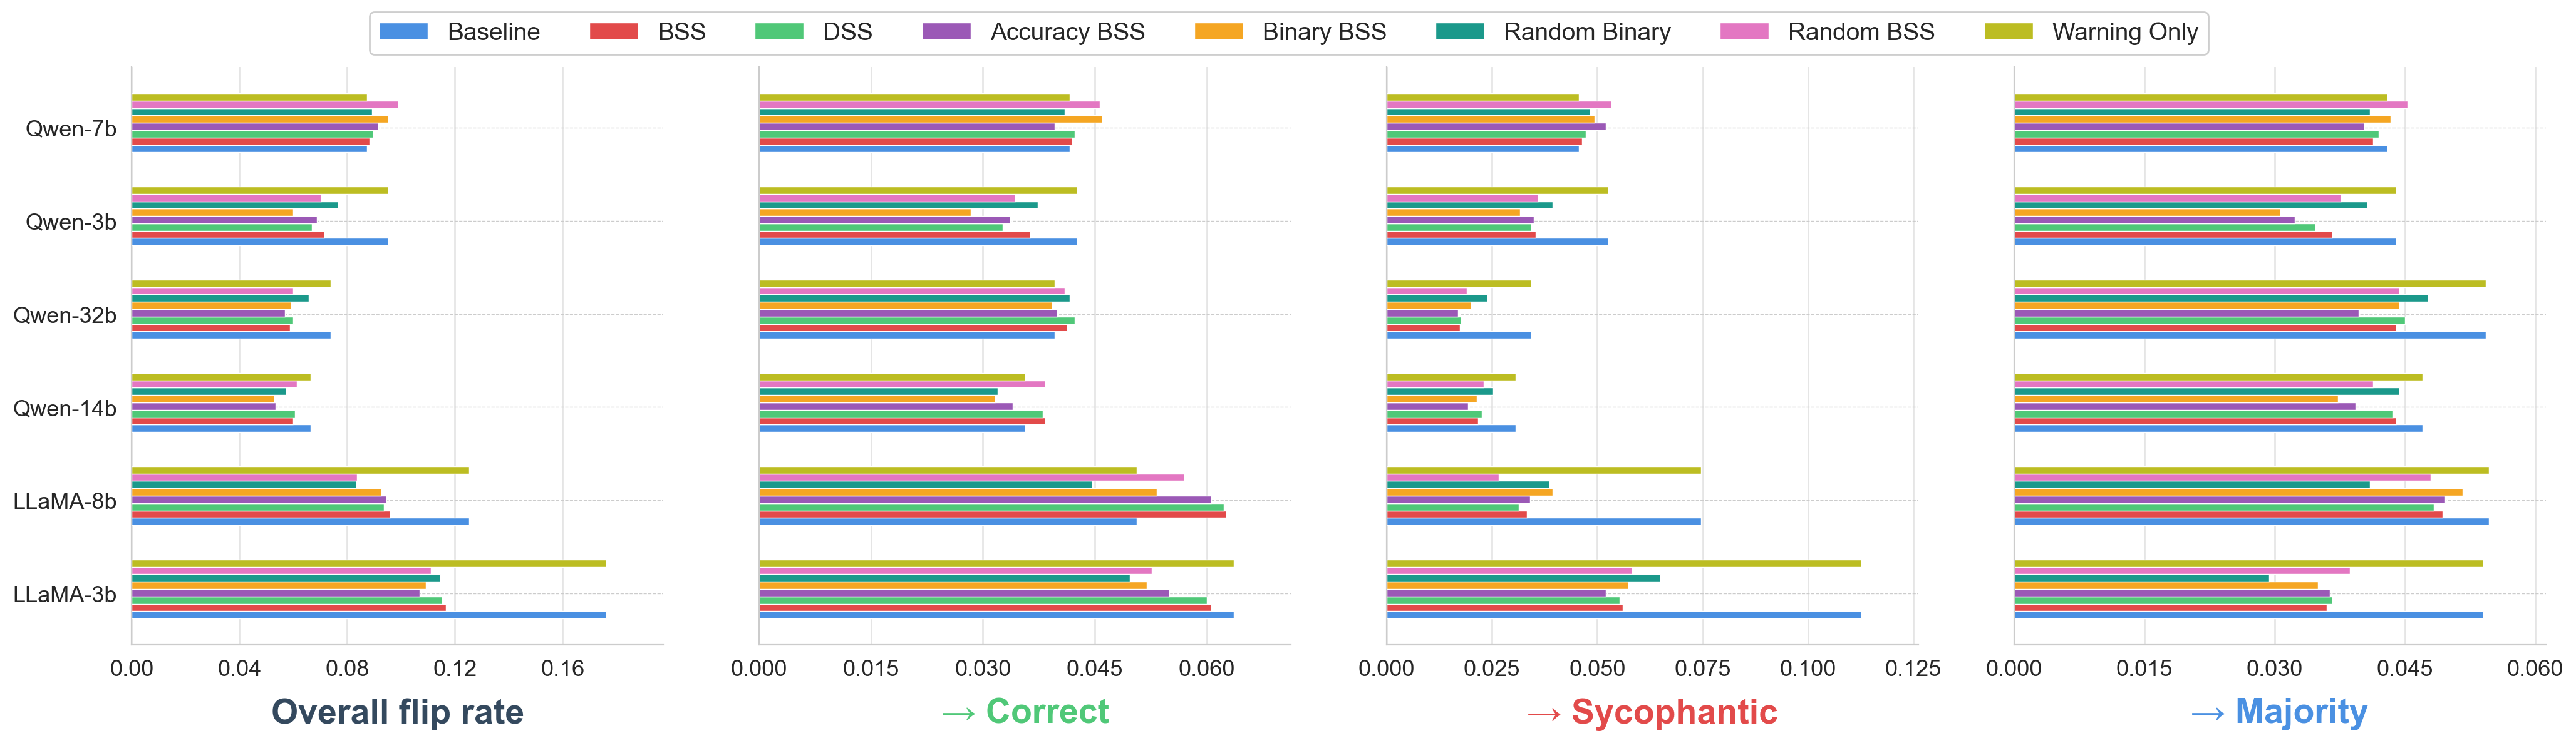

In [43]:
exps_fr = [e for e in EXPERIMENTS if e in flips and not flips[e].empty]
if exps_fr:
    _df0 = flips[exps_fr[0]]
    # evaluate.py: precomputed *_rate columns; analyze.py: counts + transitions
    if "toward_correct_rate" in _df0.columns:
        directions = [
            ("flip_rate", "Overall flip rate", "#34495e"),
            ("toward_correct_rate", "→ Correct", "#50C878"),
            ("toward_sycophantic_rate", "→ Sycophantic", "#E24A4A"),
            ("toward_majority_rate", "→ Majority", "#4A90E2"),
        ]
    else:
        directions = [
            ("flip_rate", "Overall flip rate", "#34495e"),
            ("toward_correct", "→ Correct", "#50C878"),
            ("toward_sycophantic", "→ Sycophantic", "#E24A4A"),
            ("toward_majority", "→ Majority", "#4A90E2"),
        ]
        if "away_from_correct" in _df0.columns:
            directions.append(("away_from_correct", "→ Away from correct", "#9B59B6"))

    def _flip_rate_for_row(row, col, transitions):
        if col.endswith("_rate") or col == "flip_rate":
            return float(row[col])
        return float(row[col]) / transitions if transitions else 0.0

    rate_rows = []
    for exp in exps_fr:
        df = flips[exp].copy()
        for _, row in df.iterrows():
            model = row["model"]
            trans = int(row.get("transitions", 0) or 0)
            for col, label, _ in directions:
                rate_rows.append({
                    "experiment": exp,
                    "model": model,
                    "direction": label,
                    "metric": col,
                    "rate": _flip_rate_for_row(row, col, trans),
                })
    rate_df = pd.DataFrame(rate_rows)

    models_list = sorted(rate_df["model"].unique())
    n_models = len(models_list)
    n_dirs = len(directions)

    fig, axes = plt.subplots(1, n_dirs, figsize=(5.2 * n_dirs, max(6.5, n_models * 0.85)),
                             sharey=True, squeeze=False)
    axes = axes.flatten()

    for d_idx, (col, label, base_color) in enumerate(directions):
        ax = axes[d_idx]
        sub = rate_df[rate_df["metric"] == col]
        y = np.arange(n_models) * 1.5
        bar_h = 0.95 / max(len(exps_fr), 1)
        xmax = max(sub["rate"].max() * 1.12, 0.02) if len(sub) else 0.1
        xmax = min(xmax, 1.0)

        for e_idx, exp in enumerate(exps_fr):
            edf = sub[sub["experiment"] == exp].set_index("model")
            vals = [edf.loc[m, "rate"] if m in edf.index else 0 for m in models_list]
            ax.barh(y + e_idx * bar_h - 0.4 + bar_h / 2, vals, bar_h,
                    label=NICE_NAMES.get(exp, exp), color=exp_color(exp),
                    edgecolor="white", lw=0.5)

        ax.set_yticks(y)
        ax.set_yticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_list], fontsize=14)
        ax.set_xlabel(label, fontsize=20, labelpad=10, fontweight="bold", color=base_color)
        ax.set_xlim(0, xmax)
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax.grid(True, which="major", axis="x", linestyle="-", alpha=0.5, linewidth=1.0, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=13, length=5, width=1.2)
        sns.despine(ax=ax)

    handles, labels_l = axes[0].get_legend_handles_labels()
    # Lower bbox_to_anchor y moves legend down (1 = top of figure).
    fig.legend(
        handles, labels_l, ncol=min(len(exps_fr), 8), fontsize=14,
        loc="upper center", bbox_to_anchor=(0.5, 0.93), framealpha=0.95,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.88])
    fig.subplots_adjust(wspace=0.18)
    fig.savefig(FIGS_DIR / "flip_rate_by_direction.pdf")
    fig.savefig(FIGS_DIR / "flip_rate_by_direction.png")
    plt.show()
else:
    print("No flip_summary / flip_rates data found.")


## 15. Round-1 vs Final and Stability

Plots from `round1_vs_final.csv` and `stability.csv` (run `analyze.py` first).

In [38]:
# --- Δ accuracy (final − round 1), same layout as accuracy comparison ---
exps_r1 = [e for e in EXPERIMENTS if e in round1_final and not round1_final[e].empty]
if exps_r1:
    rows = []
    for exp in exps_r1:
        for _, r in round1_final[exp].iterrows():
            rows.append({"experiment": exp, "model": r["model"], "delta": r["delta_final_minus_round1"]})
    delta_df = pd.DataFrame(rows)
    delta_df["model"] = pd.Categorical(delta_df["model"], categories=MODEL_ORDER, ordered=True)
    delta_df = delta_df.sort_values(["model", "experiment"])
    models_in_data = [m for m in MODEL_ORDER if m in delta_df["model"].unique()]
    x = np.arange(len(models_in_data))
    n_exp = len(exps_r1)
    width = 0.8 / n_exp
    fig, ax = plt.subplots(figsize=(14, 6.5))
    
    for i, exp in enumerate(exps_r1):
        exp_data = delta_df[delta_df["experiment"] == exp].set_index("model")
        vals = [exp_data.loc[m, "delta"] if m in exp_data.index else np.nan for m in models_in_data]
        ax.bar(x + i * width, vals, width, label=NICE_NAMES.get(exp, exp),
               color=exp_color(exp), edgecolor="white", linewidth=0.5)
    
    ax.axhline(0, color="0.35", lw=1.2, zorder=0)
    ax.set_xticks(x + width * (n_exp - 1) / 2)
    ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_in_data], 
                      rotation=25, ha="right", fontsize=14)
    ax.set_ylabel("Δ accuracy (final − round 1)", fontsize=22, labelpad=10)
    ax.set_title("Debate shift: final vs round-1 accuracy (same samples)", fontsize=16)
    
    # Enhanced gridlines
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.02))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.005))
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.6, linewidth=1.4, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.25, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(**LEGEND_KW, ncol=n_exp, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.78])
    fig.savefig(FIGS_DIR / "round1_vs_final_delta.pdf")
    fig.savefig(FIGS_DIR / "round1_vs_final_delta.png")
    plt.show()
else:
    print("No round1_vs_final.csv data (re-run analyze.py).")

# --- Stability rate (final answer equals round-1 answer) ---
exps_st = [e for e in EXPERIMENTS if e in stability and not stability[e].empty]
if exps_st:
    rows = []
    for exp in exps_st:
        for _, r in stability[exp].iterrows():
            rows.append({"experiment": exp, "model": r["model"], "stability_rate": r["stability_rate"]})
    stab_df = pd.DataFrame(rows)
    stab_df["model"] = pd.Categorical(stab_df["model"], categories=MODEL_ORDER, ordered=True)
    stab_df = stab_df.sort_values(["model", "experiment"])
    models_in_data = [m for m in MODEL_ORDER if m in stab_df["model"].unique()]
    x = np.arange(len(models_in_data))
    n_exp = len(exps_st)
    width = 0.8 / n_exp
    fig, ax = plt.subplots(figsize=(14, 6.5))
    
    for i, exp in enumerate(exps_st):
        exp_data = stab_df[stab_df["experiment"] == exp].set_index("model")
        vals = [exp_data.loc[m, "stability_rate"] if m in exp_data.index else np.nan for m in models_in_data]
        ax.bar(x + i * width, vals, width, label=NICE_NAMES.get(exp, exp),
               color=exp_color(exp), edgecolor="white", linewidth=0.5)
    
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x + width * (n_exp - 1) / 2)
    ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_in_data], 
                      rotation=25, ha="right", fontsize=14)
    ax.set_ylabel("Stability rate", fontsize=22, labelpad=10)
    ax.set_title("Share of samples where final answer equals round-1 answer", fontsize=16)
    
    # Enhanced gridlines
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.6, linewidth=1.4, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.25, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(**LEGEND_KW, ncol=n_exp, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.78])
    fig.savefig(FIGS_DIR / "stability_rate.pdf")
    fig.savefig(FIGS_DIR / "stability_rate.png")
    plt.show()
else:
    print("No stability.csv data (re-run analyze.py).")

No round1_vs_final.csv data (re-run analyze.py).
No stability.csv data (re-run analyze.py).
